## **Relative distance script (For the wild-type condition)**
### The relative distance is calculated in reference to the Pole-to-chromosome at anaphase onset, ie., timepoint 0. This means that the distance reduction of the distances are calculated over time. The `input file` is the mean distances file of each calculated parameter. The percentage relative distance over time is calculated and plotted. The `output file` is the visualized % relative distance plot.

In [1]:
import pandas as pd
import numpy as np
import os
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# input folder 
file_path = "D:/data/Analysis Data/python_analysis/input"
data_files = os.listdir(file_path)

# output folder
folder_save = "D:/data/Analysis Data/python_analysis/output"

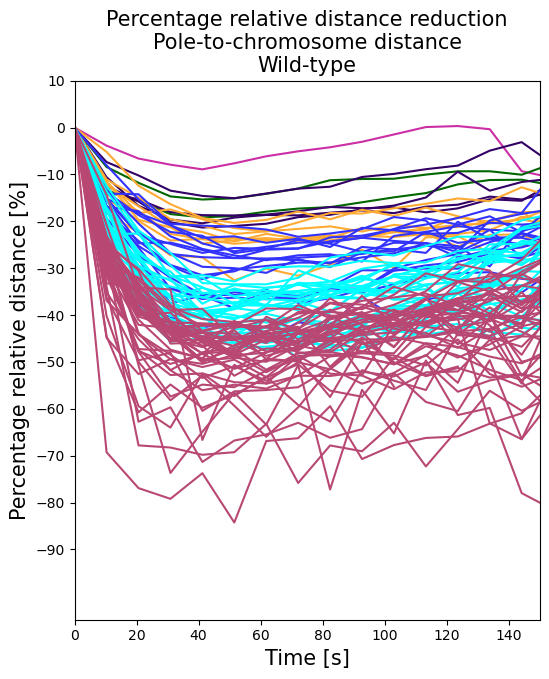

In [3]:
# create a dictionary for the color palette to color-code each cell stage
colors = {'1-cell': '#CC2EA5', 
          '2-cell': '#006600', 
          '4-cell': '#330066',
          '8-cell': '#FFAA33',
          '16-cell': '#3333FF',
          '32-cell': '#00FFFF',
          '64-cell': '#b84873'}

def plotPoleChromosome(cellname, df, ax):

    # create a list of each of the binary cell stage for both sides of the pole-to-chromosome
    cell_pc = [columnname for columnname in df if columnname.startswith(cellname)]
    
    # plt.figure(figsize=(6,6))
    plt.rcParams.update({'figure.max_open_warning': 0}) # ignore warning message on the number of files opened
    
    # make the primary plot
    for column in cell_pc:
        ax = sns.lineplot(data=df, x='time', y=column, alpha=1, color=colors[cellname])

    # plot features
    ax.axes.set_title('Percentage relative distance reduction\nPole-to-chromosome distance\nWild-type', fontsize=15)
    ax.set_xlabel("Time [s]",fontsize=15)
    ax.set_ylabel("Percentage relative distance [%]",fontsize=15)
    ax.set(ylim=(-105, 0), 
            xlim=(0, 150), 
            xticks=(np.arange(-0, 150+10, step=20)), 
            yticks=(np.arange(10, -100, step=-10)))
    
    return ax

# define the shape and size of the plot
plt.figure(figsize=(6,7))
ax1 = plt.subplot()

# read into the path directory of the files
with os.scandir(file_path) as data_files:
    for i in data_files:
        
        # read out the files from the folder
        df = pd.read_csv(i, index_col=None)
        
        # define the initial distance at time 0
        index = df.index[df['time'] == 0][0]
        
        # find the initial distance for each column
        initial_distances = df.iloc[index, :-1]

        # calculate the relative distance for each time point and column and give a header to the time column in the new dataframe
        df_rel = df.iloc[index:, :-1].sub(initial_distances).div(initial_distances).multiply(100)
        df_rel['time'] = df['time'][index:]
        
# call the function and add the characteristic color for each of the data plot
for cellname in colors.keys():
    ax1 = plotPoleChromosome(cellname, df_rel, ax1)
    
# save to different folder
ax1.figure.savefig(os.path.join(folder_save, 'relative_distance_PC_1_2(Wild-type).png'), dpi=600)
ax1.figure.savefig(os.path.join(folder_save, 'relative_distance_PC_1_2(Wild-type).svg'))
        